# Student Performance Factors Data Exploration
**Research question:** Which factors have the greatest influence on student exam performance?

## Block 1 Load & First Look

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/StudentPerformanceFactors.csv')

print(f'Rows:    {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
print()
print('Column names and data types:')
print(df.dtypes)
print()
print('First 5 rows:')
df.head()

Rows:    6607
Columns: 20

Column names and data types:
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

First 5 rows:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## Block 2 Basic Stats

In [2]:
print('Basic statistics for numeric columns:')
df.describe().round(2)

Basic statistics for numeric columns:


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.98,79.98,7.03,75.07,1.49,2.97,67.24
std,5.99,11.55,1.47,14.40,1.23,1.03,3.89
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,101.00


## Block 3 Missing Values

In [3]:
missing = df.isnull().sum()
empty = (df == '').sum()
total_missing = (missing + empty).sort_values(ascending=False)
total_missing = total_missing[total_missing > 0]

print('Columns with missing or empty values:')
for col, count in total_missing.items():
    pct = count / len(df) * 100
    print(f'  {col}: {count} missing ({pct:.1f}%)')

print()
print('Dropping rows with missing values...')
df = df.replace('', pd.NA).dropna()
print(f'Rows after cleaning: {len(df)}')

df.to_csv('data/data_cleaned.csv', index=False)
print('Saved to data/data_cleaned.csv')

Columns with missing or empty values:
  Parental_Education_Level: 90 missing (1.4%)
  Teacher_Quality: 78 missing (1.2%)
  Distance_from_Home: 67 missing (1.0%)

Dropping rows with missing values...
Rows after cleaning: 6378


OSError: Cannot save file into a non-existent directory: 'data'

## Block 4 Category Overview

In [4]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f'{col}:')
    counts = df[col].value_counts()
    for val, count in counts.items():
        pct = count / len(df) * 100
        print(f'  {val}: {count} ({pct:.1f}%)')
    print()

Parental_Involvement:
  Medium: 3251 (51.0%)
  High: 1836 (28.8%)
  Low: 1291 (20.2%)

Access_to_Resources:
  Medium: 3204 (50.2%)
  High: 1900 (29.8%)
  Low: 1274 (20.0%)

Extracurricular_Activities:
  Yes: 3807 (59.7%)
  No: 2571 (40.3%)

Motivation_Level:
  Medium: 3237 (50.8%)
  Low: 1864 (29.2%)
  High: 1277 (20.0%)

Internet_Access:
  Yes: 5893 (92.4%)
  No: 485 (7.6%)

Family_Income:
  Low: 2582 (40.5%)
  Medium: 2566 (40.2%)
  High: 1230 (19.3%)

Teacher_Quality:
  Medium: 3826 (60.0%)
  High: 1905 (29.9%)
  Low: 647 (10.1%)

School_Type:
  Public: 4434 (69.5%)
  Private: 1944 (30.5%)

Peer_Influence:
  Positive: 2553 (40.0%)
  Neutral: 2495 (39.1%)
  Negative: 1330 (20.9%)

Learning_Disabilities:
  No: 5710 (89.5%)
  Yes: 668 (10.5%)

Parental_Education_Level:
  High School: 3159 (49.5%)
  College: 1939 (30.4%)
  Postgraduate: 1280 (20.1%)

Distance_from_Home:
  Near: 3801 (59.6%)
  Moderate: 1941 (30.4%)
  Far: 636 (10.0%)

Gender:
  Male: 3688 (57.8%)
  Female: 2690 (42.2%)


## Block 5 First Look at Exam Score

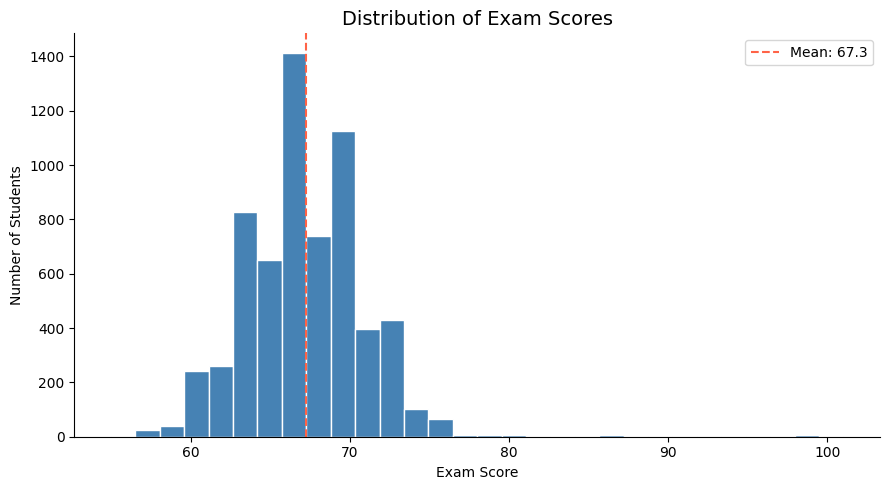

Mean:   67.25
Median: 67.00
Min:    55
Max:    101


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df['Exam_Score'], bins=30, color='steelblue', edgecolor='white')

ax.axvline(df['Exam_Score'].mean(), color='tomato', linestyle='--', linewidth=1.5,
           label=f"Mean: {df['Exam_Score'].mean():.1f}")

ax.set_title('Distribution of Exam Scores', fontsize=14)
ax.set_xlabel('Exam Score')
ax.set_ylabel('Number of Students')
ax.legend()
sns.despine()

plt.tight_layout()
plt.show()

print(f"Mean:   {df['Exam_Score'].mean():.2f}")
print(f"Median: {df['Exam_Score'].median():.2f}")
print(f"Min:    {df['Exam_Score'].min()}")
print(f"Max:    {df['Exam_Score'].max()}")